In [1]:
import json

bvh_dataset = "./datasets/mocap/dataset_v3.json"
triang_data_file = "./datasets/yolo/triangulation_select.json"
selected_names_file = "./datasets/mediapipe/selected_joint_names.json"
predicted_file = "./datasets/predicted/testset_predicted.json"


with open(bvh_dataset, 'r') as file:
    data_3d = json.load(file)

with open(selected_names_file, 'r') as file:
    selected_names = json.load(file)

with open(triang_data_file, 'r') as file:
    triangulation_data = json.load(file)
    
with open(predicted_file, 'r') as file:
    predicted = json.load(file)

with open("./datasets/train_test_split.json", "r") as f:
    train_test_split = json.load(f)

test_seq_set = train_test_split["test"]
test_seq_set

['p16s1',
 'p16s3',
 'p13s1',
 'p13s3',
 'p4s1',
 'p4s3',
 'p29s5',
 'p29s7',
 'p26s5',
 'p26s7']

In [2]:
sample_seq = test_seq_set[-1]
selected_seq = data_3d[sample_seq]

In [3]:
selected_seq[0]

{'lfemur': [-10.789226531982422, 4.250396251678467, -1.2712551355361938],
 'ltibia': [-10.887038230895996, 2.3372879028320312, -1.151773452758789],
 'lfoot': [-10.986645698547363, 0.3889118432998657, -1.0301159620285034],
 'ltoes': [-10.425353050231934, 0.22672316431999207, -1.0826137065887451],
 'rfemur': [-10.612528800964355, 4.31710958480835, -0.03724539279937744],
 'rtibia': [-10.84619426727295, 2.204470634460449, -0.2164304405450821],
 'rfoot': [-11.045454025268555, 0.4028364419937134, -0.3692552149295807],
 'rtoes': [-10.476921081542969, 0.2255333662033081, -0.32812583446502686],
 'lhumerus': [-10.566925048828125, 6.402410984039307, -1.3590080738067627],
 'lradius': [-10.995579719543457, 4.986698150634766, -1.5802587270736694],
 'lwrist': [-10.842011451721191, 4.298771381378174, -1.7230072021484375],
 'rhumerus': [-10.394771575927734, 6.290444374084473, 0.16036367416381836],
 'rradius': [-10.892578125, 5.013644218444824, 0.4360680878162384],
 'rwrist': [-10.52397632598877, 4.3323

![](./plots/joints.png)

In [4]:
SCALE_FACTOR = 255

lfoot_height_z = [frame['lfoot'][1]*SCALE_FACTOR for frame in selected_seq]
rfoot_height_z = [frame['rfoot'][1]*SCALE_FACTOR for frame in selected_seq]


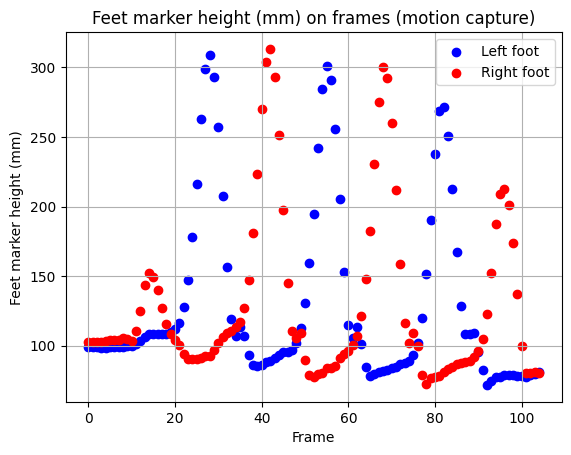

In [5]:
import matplotlib.pyplot as plt

frame_num = [i for i in range(len(lfoot_height_z))]

plt.scatter(frame_num, lfoot_height_z, color='blue', label='Left foot')
plt.scatter(frame_num, rfoot_height_z, color='red', label='Right foot')

plt.title('Feet marker height (mm) on frames (motion capture)')
plt.legend()

plt.xlabel('Frame')
plt.ylabel('Feet marker height (mm)')
plt.grid(True)
plt.show()

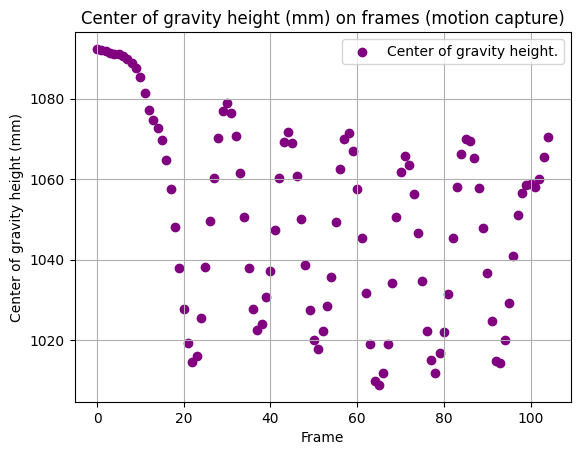

In [6]:
center_of_gravity_height = [(frame['lfemur'][1] + frame['rfemur'][1])*SCALE_FACTOR*0.5 for frame in selected_seq]

frame_num = [i for i in range(len(center_of_gravity_height))]

plt.scatter(frame_num, center_of_gravity_height, color='purple', label='Center of gravity height.')

plt.title('Center of gravity height (mm) on frames (motion capture)')
plt.legend()

plt.xlabel('Frame')
plt.ylabel('Center of gravity height (mm)')
plt.grid(True)
plt.show()

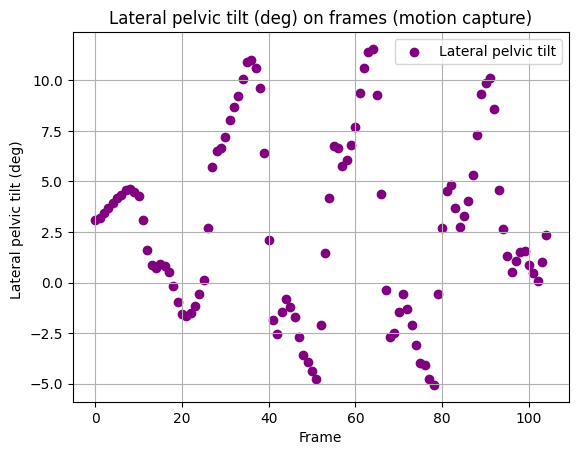

In [7]:
import math

x = 2
y = 0
z = 1

lfemur_y_z = [(frame['lfemur'][x]*SCALE_FACTOR, frame['lfemur'][z]*SCALE_FACTOR) for frame in selected_seq]
rfemur_y_z = [(frame['rfemur'][x]*SCALE_FACTOR, frame['rfemur'][z]*SCALE_FACTOR) for frame in selected_seq]


angs = []

for p1, p2 in zip(lfemur_y_z, rfemur_y_z):
    angle_radians = math.atan2(p2[0] - p1[0], p2[1] - p1[1])
    angle_degrees = 90 - math.degrees(angle_radians)
    angs.append(angle_degrees)

frame_num = [i for i in range(len(angs))]

plt.scatter(frame_num, angs, color='purple', label='Lateral pelvic tilt')

plt.title('Lateral pelvic tilt (deg) on frames (motion capture)')
plt.legend()

plt.xlabel('Frame')
plt.ylabel('Lateral pelvic tilt (deg) ')
plt.grid(True)
plt.show()

In [8]:
def find_local_minima(data, window_size=5):
    local_minima_indices = []
    
    for i in range(window_size, len(data) - window_size):
        window_prev = data[i-window_size:i]
        window_next = data[i+1:i+window_size+1]
        current = data[i]
        
        if current < min(window_prev) and current < min(window_next):
            local_minima_indices.append(i)

    return local_minima_indices


print("Local minima indices lfoot:", find_local_minima(lfoot_height_z, 10))

Local minima indices lfoot: [39, 65, 92]


In [9]:
print("Local minima indices rfoot:", find_local_minima(rfoot_height_z, 10))

Local minima indices rfoot: [23, 52, 78]


In [10]:
from scripts.parsers import parse_sequences as parse_sequence_info

file_path = 'gait3d\\ListOfSequences.txt'
sequences = parse_sequence_info(file_path)

In [11]:
for sequence, params in sequences.items():
    if params['MoCap_data']:
        lfoot_height_z = [frame['lfoot'][1]*SCALE_FACTOR for frame in data_3d[sequence]]
        rfoot_height_z = [frame['rfoot'][1]*SCALE_FACTOR for frame in data_3d[sequence]]
        left_minima = find_local_minima(lfoot_height_z, 10)
        right_minima = find_local_minima(rfoot_height_z, 10)
        
        sorted_minima = sorted(right_minima + left_minima)
        order = ""

        for minim in sorted_minima:
            if minim in left_minima:
                order += "L"
            else:
                order += "R"

        alternately = True
        for i in range(len(order) - 1):
            if order[i] == order[i+1]:
                alternately = False
                break

        print(f"{sequence} | {'OK' if alternately else 'NO NO NO NO NO' } | {order} | L: {left_minima} | R: {right_minima}")

p1s1 | OK | LRLRLRL | L: [19, 51, 83, 114] | R: [36, 67, 98]
p1s2 | OK | LRLRLR | L: [22, 53, 84] | R: [38, 68, 99]
p1s3 | OK | LRLRLRL | L: [17, 47, 77, 107] | R: [32, 62, 92]
p1s4 | OK | LRLRLR | L: [18, 48, 78] | R: [34, 64, 95]
p2s1 | OK | RLRLRLRL | L: [36, 66, 96, 123] | R: [23, 52, 81, 112]
p2s2 | OK | RLRLRLR | L: [29, 56, 84] | R: [18, 44, 70, 99]
p2s3 | OK | LRLRLRL | L: [19, 48, 76, 106] | R: [34, 63, 91]
p2s4 | OK | LRLRLRLR | L: [10, 35, 61, 88] | R: [23, 50, 74, 103]
p3s1 | OK | LRLRLRLR | L: [16, 48, 78, 104] | R: [35, 64, 94, 127]
p3s2 | OK | RLRLRLR | L: [27, 52, 80] | R: [14, 40, 66, 95]
p3s3 | OK | LRLRLRLR | L: [17, 50, 79, 109] | R: [34, 65, 96, 128]
p3s4 | OK | RLRLRLR | L: [36, 61, 87] | R: [23, 49, 74, 100]
p4s1 | OK | LRLRLR | L: [22, 53, 84] | R: [38, 69, 101]
p4s2 | OK | LRLRLR | L: [20, 51, 81] | R: [37, 67, 97]
p4s3 | OK | RLRLRL | L: [36, 67, 101] | R: [20, 51, 83]
p4s4 | OK | RLRLRL | L: [35, 65, 96] | R: [18, 50, 81]
p5s1 | OK | RLRLRLRL | L: [36, 69, 10

In [12]:
import math

def round_to_sigfigs(num, sig_figs=5):
    if num == 0:
        return 0
    return round(num, sig_figs - int(math.floor(math.log10(abs(num)))) - 1)

In [13]:
from utils.gait_parameters_extractor_v2 import GaitParametersExtractorV2 as GaitParametersExtractor
from utils.gait_parameters_extractor import CoordinatesIdx

In [14]:
# import math
# import numpy as np
# from dataclasses import dataclass, field, fields
# from typing import Sequence, Mapping, Tuple


# @dataclass
# class CoordinatesIdx:
#     x: int = field(default=0)
#     y: int = field(default=1)
#     z: int = field(default=2)   

#     def __post_init__(self):
#         assert self.x != self.y
#         assert self.x != self.z
#         assert self.y != self.z
#         for field in fields(self):
#             assert getattr(self, field.name) in [0, 1, 2]


# class GaitParametersExtractor():
#     FPS = 25
#     FRAME_TIME = 1/FPS 
#     """
#     Class to extract basic gait parameters based on 3D frame.
#     """
#     def __init__(self, sequence_parameters: Sequence[Mapping], coordintates_idx: CoordinatesIdx=CoordinatesIdx, scale_factor:int=255):
#         self.seq_params = sequence_parameters
#         self.scale_factor = scale_factor
#         self.c_idx = coordintates_idx
#         self.l_steps, self.r_steps = self._find_step_frames()
#         self.all_steps = sorted(self.l_steps + self.r_steps)
#         self.start_position, self.finish_position = self._find_start_and_finish_position()

#     def _find_start_and_finish_position(self) -> Tuple[Tuple[float, float], Tuple[float, float]]:
#         """
#         Function to find start and finish position of sequence - useful to obtain 
#         """
#         start_position = ((self.seq_params[0]['lfoot'][self.c_idx.x] + 
#                            self.seq_params[0]['rfoot'][self.c_idx.x]) / 2 * self.scale_factor,
#                            (self.seq_params[0]['lfoot'][self.c_idx.y] + 
#                            self.seq_params[0]['rfoot'][self.c_idx.y]) / 2 * self.scale_factor)

#         finish_position = ((self.seq_params[-1]['lfoot'][self.c_idx.x] + 
#                             self.seq_params[-1]['rfoot'][self.c_idx.x]) / 2 * self.scale_factor,
#                            (self.seq_params[-1]['lfoot'][self.c_idx.y] + 
#                             self.seq_params[-1]['rfoot'][self.c_idx.y]) / 2 * self.scale_factor)

#         return start_position, finish_position
                    

#     def _find_step_frames(self) -> Tuple[Sequence, Sequence]:
#         """
#         Function to find step frames (minimum foot marker position in sequence.
#         Output as two lists - first with frames number with left foot steps, second for right foot.
#         """
#         lfoot_height_z = [frame['lfoot'][self.c_idx.z]*SCALE_FACTOR for frame in self.seq_params]
#         rfoot_height_z = [frame['rfoot'][self.c_idx.z]*SCALE_FACTOR for frame in self.seq_params]
#         left_minima = self.__find_local_minima(lfoot_height_z, 10)
#         right_minima = self.__find_local_minima(rfoot_height_z, 10)

#         if not self.__check_if_left_right_alternately(left_minima, right_minima):
#             # If not left right alternately check without first or last item on list - start and end of sequence might be problematic
#             if left_minima[0] <= right_minima[0] and self.__check_if_left_right_alternately(left_minima[1:], right_minima):
#                 left_minima = left_minima[1:]
#                 print("First left step recognized as probably marked incorrectly and removed")
#             elif right_minima[0] <= left_minima[0] and self.__check_if_left_right_alternately(left_minima, right_minima[1:]):
#                 right_minima = right_minima[1:]
#                 print("First right step recognized as probably marked incorrectly and removed")
#             elif left_minima[-1] <= right_minima[-1] and self.__check_if_left_right_alternately(left_minima[:-1], right_minima):
#                 left_minima = left_minima[:-1]
#                 print("Last left step recognized as probably marked incorrectly and removed")
#             elif right_minima[-1] <= left_minima[-1] and self.__check_if_left_right_alternately(left_minima, right_minima[:-1]):
#                 right_minima = right_minima[:-1]
#                 print("Last right step recognized as probably marked incorrectly and removed")

#         if not self.__check_if_left_right_alternately(left_minima, right_minima):
#             print("Falied to find proper step frame keys")
#             return [], []

#         return left_minima, right_minima

#     def calculate_pelvic_parameters(self) -> Sequence[float]:
#         """
#         Center of gravity height - distance from center of gravity (center of pelvis) to ground level, diff mean difference between minmum and amximum CoG height during step. 
#         Lateral pelvic tilt - angle between vertical and line going through hips
#         Pelvis rotatoion - angle between line going from start to end position of the walker, and line going through hips. 
#         Output as nine floats - left to right mean diff of CoG height, right to left mean diff of CoG height, total mean diff of CoG height,
#         Left to right mean diff of pelvic tilt, right to left mean diff of pelvic tilt, total mean diff of pelvic tilt,
#         Mean pelvis rotation for left foot, mean pelvis rotation for right foot, mean pelvis rotation for all steps.
#         """
#         center_of_gravity_height = [(frame['lfemur'][self.c_idx.z] + frame['rfemur'][self.c_idx.z])*self.scale_factor*0.5 for frame in self.seq_params]

#         cog_diff_heights = []
#         l_r_cog_diff_heights = []
#         r_l_cog_diff_heights = []
        
#         for i in range(len(self.all_steps) - 1):
#             start_frame, end_frame = self.all_steps[i], self.all_steps[i+1]
#             cog_step = center_of_gravity_height[start_frame: end_frame]
#             min_cog_height = min(cog_step)
#             max_cog_height = max(cog_step)
#             cog_height_difference = max_cog_height - min_cog_height
            
#             cog_diff_heights.append(cog_height_difference)
#             if self.all_steps[i] in self.l_steps:
#                 l_r_cog_diff_heights.append(cog_height_difference)
#             else:
#                 r_l_cog_diff_heights.append(cog_height_difference)

        
#         lfemur_x_z = [(frame['lfemur'][self.c_idx.x]*self.scale_factor, frame['lfemur'][self.c_idx.z]*self.scale_factor) for frame in self.seq_params]
#         rfemur_x_z = [(frame['rfemur'][self.c_idx.x]*self.scale_factor, frame['rfemur'][self.c_idx.z]*self.scale_factor) for frame in self.seq_params]
        
#         lateral_pelvic_tilt = []
        
#         for p1, p2 in zip(lfemur_x_z, rfemur_x_z):
#             angle_radians = math.atan2(p2[0] - p1[0], p2[1] - p1[1])
#             angle_degrees = math.degrees(angle_radians)
#             lateral_pelvic_tilt.append(angle_degrees)

#         lateral_pelvic_tilt_diff = []
#         l_r_lateral_pelvic_tilt_diff = []
#         r_l_lateral_pelvic_tilt_diff = []

#         for i in range(len(self.all_steps) - 1):
#             start_frame, end_frame = self.all_steps[i], self.all_steps[i+1]
#             lpt_step = lateral_pelvic_tilt[start_frame: end_frame]
#             min_step_lpt = min(lpt_step)
#             max_step_lpt = max(lpt_step)

#             step_lpt_diff = abs(max_step_lpt - min_step_lpt)

#             lateral_pelvic_tilt_diff.append(step_lpt_diff)

#             if self.all_steps[i] in self.l_steps:
#                 l_r_lateral_pelvic_tilt_diff.append(step_lpt_diff)
#             else:
#                 r_l_lateral_pelvic_tilt_diff.append(step_lpt_diff)

#         lfemur_x_y = [(frame['lfemur'][self.c_idx.x]*self.scale_factor, frame['lfemur'][self.c_idx.y]*self.scale_factor) for frame in self.seq_params]
#         rfemur_x_y = [(frame['rfemur'][self.c_idx.x]*self.scale_factor, frame['rfemur'][self.c_idx.y]*self.scale_factor) for frame in self.seq_params]

#         pelvis_rotation = []
        
#         for p1, p2 in zip(lfemur_x_y, rfemur_x_y):
#             pelvis_rotation.append(
#                 self.__angle_between_vectors(
#                     v1=(p1[0] - p2[0], p1[1] - p2[1]), 
#                     v2=(self.start_position[0] - self.finish_position[0], 
#                         self.start_position[1] - self.finish_position[1])
#                 )
#             )

#         l_pelvis_rotation = [abs(pelvis_rotation[frame]-90) for frame in self.l_steps]
#         r_pelvis_rotation = [abs(pelvis_rotation[frame]-90) for frame in self.r_steps]
#         prlvis_rotation = l_pelvis_rotation + r_pelvis_rotation

#         return (self._mean(l_r_cog_diff_heights), self._mean(r_l_cog_diff_heights), self._mean(cog_diff_heights), 
#                 self._mean(l_r_lateral_pelvic_tilt_diff), self._mean(r_l_lateral_pelvic_tilt_diff), self._mean(lateral_pelvic_tilt_diff), 
#                 self._mean(l_pelvis_rotation), self._mean(r_pelvis_rotation), self._mean(prlvis_rotation), )


#     def calculate_mean_stride_time_and_length(self) -> Sequence[float]:
#         """
#         Stride time - the time between the consecutive initial contacts of the same foot.
#         Stride length - the distance between the consecutive initial contacts of the same foot. 
#         Output as six floats: left foot mean stride time, right foot mean stride time, mean stride time,
#         left foot mean stride length, right foot mean stride length, mean stride length.
#         Time unit is [s], distance unit is [mm].
#         """
        
#         l_stride_times = []
#         l_stride_dist = []
#         for i in range(len(self.l_steps)-1):
#             l_stride_times.append(self.FRAME_TIME * (self.l_steps[i+1] - self.l_steps[i]))
#             l_stride_dist.append(
#                 self._calculate_distance_between_projections(
#                     self.seq_params[self.l_steps[i+1]]['lfoot'],
#                     self.seq_params[self.l_steps[i]]['lfoot']
#                 )
#             )

#         r_stride_times = []
#         r_stride_dist = []
#         for i in range(len(self.r_steps)-1):
#             r_stride_times.append(self.FRAME_TIME * (self.r_steps[i+1] - self.r_steps[i]))
#             r_stride_dist.append(
#                 self._calculate_distance_between_projections(
#                     self.seq_params[self.r_steps[i+1]]['rfoot'],
#                     self.seq_params[self.r_steps[i]]['rfoot']
#                 )
#             )

#         stride_times = r_stride_times + l_stride_times
#         l_mean_stride_time = sum(l_stride_times)/len(l_stride_times)
#         r_mean_stride_time = sum(r_stride_times)/len(r_stride_times)
#         total_mean_stride_time = sum(stride_times)/len(stride_times)

#         stride_dist = r_stride_dist + l_stride_dist
#         l_mean_stride_dist = sum(l_stride_dist)/len(l_stride_dist)
#         r_mean_stride_dist = sum(r_stride_dist)/len(r_stride_dist)
#         total_mean_stride_dist = sum(stride_dist)/len(stride_dist)
        
#         return (l_mean_stride_time, r_mean_stride_time, total_mean_stride_time, 
#                 l_mean_stride_dist, r_mean_stride_dist, total_mean_stride_dist)

#     def calculate_mean_step_time_length_and_width(self) -> Sequence[float]:
#         """
#         Step time - the time between the initial contact of one foot and the initial contact of the contralateral foot.
#         Step length - the distance between the initial contact of one foot and the initial contact of the contralateral foot.
#         Step width - the distance between the points of initial contact of opposite feet during a step.
#         Output as nine floats: left to right foot mean step time, right to left foot mean step time, total mean step time,
#         left to right foot mean step length, right to left foot mean step length, total mean step length,
#         left to right foot mean step width, right to left foot mean step width, total mean step width.
#         Time unit is [s], distance unit is [mm].
#         """

#         step_times = []
#         l_r_step_dist = []
#         r_l_step_dist = []
#         l_r_step_width = []
#         r_l_step_width = []
#         for i in range(len(self.all_steps)-1):
#             step_times.append(self.FRAME_TIME * (self.all_steps[i+1] - self.all_steps[i]))
#             if self.all_steps[i] in self.l_steps:
#                 l_r_step_dist.append(
#                     self._calculate_distance_between_projections(
#                         self.seq_params[self.all_steps[i]]['lfoot'],
#                         self.seq_params[self.all_steps[i+1]]['rfoot'],
#                     )
#                 )

#                 l_r_step_width.append(
#                     self._calculate_distance_to_gait_axis(self.seq_params[self.all_steps[i+1]]['rfoot']) + 
#                     self._calculate_distance_to_gait_axis(self.seq_params[self.all_steps[i]]['lfoot'])
#                 )

                
#             else:
#                 r_l_step_dist.append(
#                     self._calculate_distance_between_projections(
#                         self.seq_params[self.all_steps[i]]['rfoot'],
#                         self.seq_params[self.all_steps[i+1]]['lfoot'],
#                     )
#                 )

#                 r_l_step_width.append(
#                     self._calculate_distance_to_gait_axis(self.seq_params[self.all_steps[i+1]]['lfoot']) + 
#                     self._calculate_distance_to_gait_axis(self.seq_params[self.all_steps[i]]['rfoot'])
#                 )

#         if self.all_steps[0] == self.l_steps[0]:
#             l_r_step_time = step_times[0::2]
#             r_l_step_time = step_times[1::2]
#         else:
#             l_r_step_time = step_times[1::2]
#             r_l_step_time = step_times[0::2]

#         l_r_mean_step_times = sum(l_r_step_time)/len(l_r_step_time)
#         r_l_mean_step_times = sum(r_l_step_time)/len(r_l_step_time)
#         total_mean_step_times = sum(step_times)/len(step_times)

#         step_dist = l_r_step_dist + r_l_step_dist
#         total_mean_step_distance = sum(step_dist)/len(step_dist)
#         l_r_mean_step_dist = sum(l_r_step_dist)/len(l_r_step_dist)
#         r_l_mean_step_dist = sum(r_l_step_dist)/len(r_l_step_dist)

#         step_width = l_r_step_width + r_l_step_width
#         total_mean_step_width = sum(step_width)/len(step_width)
#         l_r_mean_step_width = sum(l_r_step_width)/len(l_r_step_width)
#         r_l_mean_step_width = sum(r_l_step_width)/len(r_l_step_width)
        
#         return (l_r_mean_step_times, r_l_mean_step_times, total_mean_step_times, 
#                 l_r_mean_step_dist, r_l_mean_step_dist, total_mean_step_distance,
#                 l_r_mean_step_width, r_l_mean_step_width, total_mean_step_width)

#     def _calculate_distance_to_gait_axis(self, point: Sequence[float]) -> float:
#         """
#         Calculate the distance from given point to the line defined by start and end participant position.
#         Each point is a tuple of (x, y).
#         """
#         x1, y1 = self.start_position
#         x2, y2 = self.finish_position

#         x0, y0 = (point[self.c_idx.x] * self.scale_factor, point[self.c_idx.y] * self.scale_factor)
        
#         numerator = abs((x2 - x1) * (y1 - y0) - (x1 - x0) * (y2 - y1))
#         denominator = math.hypot(x2 - x1, y2 - y1)
                
#         return numerator / denominator

#     def _project_point_onto_line(self, point: Tuple[float, float]) -> Tuple[float, float]:
#         """
#         Projects a point onto the line defined by p_start and p_stop.
#         """
#         p_start = np.array(self.start_position)
#         p_stop = np.array(self.finish_position)
#         point = np.array(point)
        
#         line_vec = p_stop - p_start
#         line_unit = line_vec / np.linalg.norm(line_vec)
        
#         point_vec = point - p_start
#         projection_length = np.dot(point_vec, line_unit)
        
#         projection = p_start + projection_length * line_unit
#         return projection

#     def _calculate_distance_between_projections(self, point_a: Sequence[float], point_b: Sequence[float]):
#         """
#         Projects a and b onto the line through start and finish position, 
#         and returns the distance between those projections.
#         """
        
#         proj_a = self._project_point_onto_line((point_a[self.c_idx.x] * self.scale_factor, point_a[self.c_idx.y] * self.scale_factor))
#         proj_b = self._project_point_onto_line((point_b[self.c_idx.x] * self.scale_factor, point_b[self.c_idx.y] * self.scale_factor))
        
#         return np.linalg.norm(proj_b - proj_a)


#     @staticmethod
#     def __find_local_minima(data, window_size:int=5) -> Sequence[int]:
#         local_minima_indices = []
        
#         for i in range(window_size, len(data) - window_size):
#             window_prev = data[i-window_size:i]
#             window_next = data[i+1:i+window_size+1]
#             current = data[i]
            
#             if current < min(window_prev) and current < min(window_next):
#                 local_minima_indices.append(i)
    
#         return local_minima_indices

#     @staticmethod
#     def __check_if_left_right_alternately(left_minima, right_minima):
#         sorted_minima = sorted(right_minima + left_minima)
#         order=""

#         for minim in sorted_minima:
#             if minim in left_minima:
#                 order += "L"
#             else:
#                 order += "R"

#         alternately = True
#         for i in range(len(order) - 1):
#             if order[i] == order[i+1]:
#                 alternately = False
#                 break

#         return alternately

#     import numpy as np

#     @staticmethod
#     def __project_point_on_plane(point, plane_point, plane_normal):
#         """
#         Projects a 3D point onto a plane.Returns projected 3D point on the plane.
#         """
#         plane_normal = plane_normal / np.linalg.norm(plane_normal)
#         vector_to_point = point - plane_point
#         distance = np.dot(vector_to_point, plane_normal)
#         projected_point = point - distance * plane_normal
#         return projected_point
        
#     @staticmethod
#     def __angle_between_vectors(v1, v2):
#         """
#         Calculates the angle in degrees between two N-dimension vectors.
#         """
#         dot_product = np.dot(v1, v2)
#         magnitude_v1 = np.linalg.norm(v1)
#         magnitude_v2 = np.linalg.norm(v2)
    
#         if magnitude_v1 == 0 or magnitude_v2 == 0:
#             return 0.0
    
#         cosine_angle = dot_product / (magnitude_v1 * magnitude_v2)
#         cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
#         angle_rad = np.arccos(cosine_angle)
#         angle_deg = np.degrees(angle_rad)
#         return angle_deg

#     @staticmethod
#     def _mean(sequence: list) -> float:
#         return sum(sequence)/len(sequence)

#     def _calculate_angle_between_joints(self, joint_pair_1:tuple, joint_pair_2:tuple, frame_number:int):
#         p1 = np.array([self.start_position[0], self.start_position[1], 0.0])
#         p2 = np.array([self.start_position[0], self.start_position[1], 1.0])
#         p3 = np.array([self.finish_position[0], self.finish_position[1], 0.0])
        
#         A_orig = np.array(self.seq_params[frame_number][joint_pair_1[0]]) * self.scale_factor
#         B_orig = np.array(self.seq_params[frame_number][joint_pair_1[1]]) * self.scale_factor
#         C_orig = np.array(self.seq_params[frame_number][joint_pair_2[0]]) * self.scale_factor
#         D_orig = np.array(self.seq_params[frame_number][joint_pair_2[1]]) * self.scale_factor

#         new_order_indices = [self.c_idx.x, self.c_idx.y, self.c_idx.z]

#         A = A_orig[new_order_indices]
#         B = B_orig[new_order_indices]
#         C = C_orig[new_order_indices]
#         D = D_orig[new_order_indices]
        
#         v1 = p2 - p1
#         v2 = p3 - p1
#         plane_normal = np.cross(v1, v2)
        
#         if np.linalg.norm(plane_normal) == 0:
#             print("Error: The points p1, p2, and p3 are collinear and do not define a unique plane.")
#             return 0
#         else:
#             A_proj = self.__project_point_on_plane(A, p1, plane_normal)
#             B_proj = self.__project_point_on_plane(B, p1, plane_normal)
#             C_proj = self.__project_point_on_plane(C, p1, plane_normal)
#             D_proj = self.__project_point_on_plane(D, p1, plane_normal)
        
#             # print(f"Original A: {A}, Projected A: {A_proj}")
#             # print(f"Original B: {B}, Projected B: {B_proj}")
#             # print(f"Original C: {C}, Projected C: {C_proj}")
#             # print(f"Original D: {D}, Projected D: {D_proj}")
        
#             line1_direction = B_proj - A_proj
#             line2_direction = D_proj - C_proj
        
#             if np.linalg.norm(line1_direction) == 0 or np.linalg.norm(line2_direction) == 0:
#                 print("One or both projected lines are effectively points (start and end points are the same). Angle is undefined or 0.")
#                 return 0
#             else:
#                 angle = self.__angle_between_vectors(line1_direction, line2_direction)
#                 return angle

#     def get_legs_angle(self):
#         legs_angles = []
#         for i in range(len(self.seq_params)):
#             legs_angles.append(self._calculate_angle_between_joints(('rtibia','rfemur'), ('ltibia', 'lfemur'), i))
#         return legs_angles

#     def get_knees_angle(self):
#         l_knee_angles = []
#         r_knee_angles = []
#         for i in range(len(self.seq_params)):
#             r_knee_angles.append(self._calculate_angle_between_joints(('rfemur', 'rtibia'), ('rfoot', 'rtibia'), i))
#             l_knee_angles.append(self._calculate_angle_between_joints(('lfemur', 'ltibia'), ('lfoot', 'ltibia'), i))
#         return l_knee_angles, r_knee_angles

#     def get_hip_angle(self):
#         l_hip_angles = []
#         r_hip_angles = []
#         for i in range(len(self.seq_params)):
#             r_hip_angles.append(self._calculate_angle_between_joints(('rhumerus', 'rfemur'), ('rtibia', 'rfemur'), i))
#             l_hip_angles.append(self._calculate_angle_between_joints(('lhumerus', 'lfemur'), ('ltibia', 'lfemur'), i))
#         return l_hip_angles, r_hip_angles

#     def get_l_r_joint_angle(self, joint1: str, joint2: str, joint3: str):
#         l_angles = []
#         r_angles = []
#         for i in range(len(self.seq_params)):
#             l_angles.append(self._calculate_angle_between_joints((f'l{joint1}', f'l{joint2}'), (f'l{joint3}', f'l{joint2}'), i))
#             r_angles.append(self._calculate_angle_between_joints((f'r{joint1}', f'r{joint2}'), (f'r{joint3}', f'r{joint2}'), i))
#         return l_angles, r_angles

#     def calculate_avg_max_hip_angle_per_stride(self) -> tuple[float, float, float]:
#         """
#         Calculate max hip angle for each step in sequence
#         Returns mean of those max hip angle for steps of left, right and both feet.
#         """
        
#         l_hip_angles, r_hip_angles = self.get_hip_angle()
#         l_max_hip_angle_diff, r_max_hip_angle_diff, = [], [] 
       
#         for i in range(len(self.l_steps)-1):
#             l_max_hip_angle_diff.append(
#                 max(l_hip_angles[self.l_steps[i]: self.l_steps[i+1]])
#                 - min(l_hip_angles[self.l_steps[i]: self.l_steps[i+1]])
#             )

#         for i in range(len(self.r_steps)-1):
#             r_max_hip_angle_diff.append(
#                 max(r_hip_angles[self.r_steps[i]: self.r_steps[i+1]])
#                 - min(r_hip_angles[self.r_steps[i]: self.r_steps[i+1]])
#             )
        
#         return self._mean(l_max_hip_angle_diff), self._mean(r_max_hip_angle_diff), self._mean(l_max_hip_angle_diff + r_max_hip_angle_diff)

#     def calculate_avg_max_knee_angle_per_stride(self) -> tuple[float, float, float]:
#         """
#         Calculate max knee angle for each stride in sequence
#         Returns mean of those max knee angle for steps of left, right and both feet.
#         """
        
#         l_knee_angles, r_knee_angles = self.get_knees_angle()
#         l_max_knee_angle_diff, r_max_knee_angle_diff, = [], [] 
       
#         for i in range(len(self.l_steps)-1):
#             l_max_knee_angle_diff.append(
#                 max(l_knee_angles[self.l_steps[i]: self.l_steps[i+1]])
#                 - min(l_knee_angles[self.l_steps[i]: self.l_steps[i+1]])
#             )

#         for i in range(len(self.r_steps)-1):
#             r_max_knee_angle_diff.append(
#                 max(r_knee_angles[self.r_steps[i]: self.r_steps[i+1]])
#                 - min(r_knee_angles[self.r_steps[i]: self.r_steps[i+1]])
#             )

#         return self._mean(l_max_knee_angle_diff), self._mean(r_max_knee_angle_diff), self._mean(l_max_knee_angle_diff + r_max_knee_angle_diff)

#     def calculate_avg_max_legs_angle_for_steps(self) -> tuple[float, float, float]:
#         """
#         Calculate max legs angle in each step.
#         Returns mean max legs angle for left to right foot step, right to left foot step and all steps.
#         """
#         l_r_step_l_angle, r_l_step_l_angle = [], []
#         legs_angle = self.get_legs_angle()
#         for i in range(len(self.all_steps)-1):
#             if self.all_steps[i] in self.l_steps:
#                 l_r_step_l_angle.append(
#                     max(legs_angle[self.all_steps[i]], legs_angle[self.all_steps[i]+1])
#                 )

#             else:
#                 r_l_step_l_angle.append(
#                     max(legs_angle[self.all_steps[i]], legs_angle[self.all_steps[i]+1])
#                 )

#         return  self._mean(l_r_step_l_angle), self._mean(r_l_step_l_angle), self._mean(r_l_step_l_angle + l_r_step_l_angle)

#     def calculate_avg_max_ankle_angle_per_stride(self) -> tuple[float, float, float]:
#         """
#         Calculate max ankle angle difference for each stride in sequence
#         """
#         l_angles, r_angles = self.get_l_r_joint_angle('tibia', 'foot', 'toes')
#         l_max_angle_diff, r_max_angle_diff, = [], []

#         # s = 30
#         # e = 55
#         # print([round_to_sigfigs(number, 5) for number in l_angles[s:e]])
#         # print([round_to_sigfigs(number, 5) for number in r_angles[s:e]])

#         for i in range(len(self.l_steps)-1):
#             l_max_angle_diff.append(
#                 max(l_angles[self.l_steps[i]: self.l_steps[i+1]])
#                 - min(l_angles[self.l_steps[i]: self.l_steps[i+1]])
#             )

#         for i in range(len(self.r_steps)-1):
#             r_max_angle_diff.append(
#                 max(r_angles[self.r_steps[i]: self.r_steps[i+1]])
#                 - min(r_angles[self.r_steps[i]: self.r_steps[i+1]])
#             )

#         return self._mean(l_max_angle_diff), self._mean(r_max_angle_diff), self._mean(l_max_angle_diff + r_max_angle_diff)


#     def calculate_avg_max_humerus_angle_per_stride(self) -> tuple[float, float, float]:
#         """
#         Calculate max humerus angle difference for each stride in sequence
#         """
#         l_angles, r_angles = self.get_l_r_joint_angle('femur', 'humerus', 'radius')
#         l_max_angle_diff, r_max_angle_diff, = [], []

#         print(f'{self.l_steps = }')
#         print(f'{self.r_steps = }')
        
#         s = 30
#         e = 60
#         print([round_to_sigfigs(number, 4) for number in l_angles[self.l_steps[0]:self.l_steps[1]]])
#         print([round_to_sigfigs(number, 4) for number in r_angles[self.r_steps[0]:self.r_steps[1]]])

#         for i in range(len(self.l_steps)-1):
#             l_max_angle_diff.append(
#                 max(l_angles[self.l_steps[i]: self.l_steps[i+1]])
#                 - min(l_angles[self.l_steps[i]: self.l_steps[i+1]])
#             )

#         for i in range(len(self.r_steps)-1):
#             r_max_angle_diff.append(
#                 max(r_angles[self.r_steps[i]: self.r_steps[i+1]])
#                 - min(r_angles[self.r_steps[i]: self.r_steps[i+1]])
#             )

#         return self._mean(l_max_angle_diff), self._mean(r_max_angle_diff), self._mean(l_max_angle_diff + r_max_angle_diff)




In [15]:
person = 26

print('---------------------------------------------------------------')

for i in range(1, 5):
    print('\n---------------------------------------------------------------')

    gpe = GaitParametersExtractor(data_3d[f'p{person}s{i}'], CoordinatesIdx(2, 0, 1))
    # print(gpe.calculate_avg_humerus_angle_per_step())
    print(gpe.calculate_avg_max_elbow_angle_per_stride())


---------------------------------------------------------------

---------------------------------------------------------------
(12.909369065365993, 16.73761717858443, 14.823493121975211)

---------------------------------------------------------------
(11.09781293672198, 16.777303410020487, 13.937558173371233)

---------------------------------------------------------------
(7.045235870233398, 18.315647157658596, 14.55884339518353)

---------------------------------------------------------------
(7.067971814419579, 12.58366916724885, 9.825820490834214)


In [16]:
for i in range(1, 9):
    print(f'p30s{i}')
    gpe = GaitParametersExtractor(data_3d[f'p30s{i}'], CoordinatesIdx(2, 0, 1))
    # print(gpe.start_position, gpe.finish_position)
    # print(gpe.l_steps, gpe.r_steps)
    print(gpe.calculate_mean_stride_time_and_length())
    print(gpe.calculate_mean_step_time_length_and_width())
    print(gpe.calculate_avg_max_hip_angle_per_stride())
    print(gpe.calculate_avg_max_knee_angle_per_stride())
    print(gpe.calculate_avg_max_legs_angle_for_steps())
    print(gpe.calculate_avg_max_ankle_angle_per_stride())
    print(gpe.calculate_avg_humerus_angle_per_step())
    print(gpe.calculate_avg_max_elbow_angle_per_stride())
    print(gpe.calculate_pelvic_parameters())
    

p30s1
(1.1600000000000001, 1.12, 1.1400000000000001, 1625.8909585933586, 1620.924113727207, 1623.4075361602827)
(0.54, 0.6000000000000001, 0.5760000000000001, 819.9319001434092, 814.7837380682289, 816.8430028983009, 132.65444764739223, 133.4605871492988, 133.13813134853618)
(20.98943915183152, 34.043459220112894, 27.516449185972206)
(67.09555051236927, 72.67961912302789, 69.88758481769858)
(28.83004541296075, 43.09027509163733, 37.3861832201667)
(34.46006015389157, 31.467330730545697, 32.963695442218636)
(23.880468765642618, 8.135605116885921, 20.657291484680226, 10.872853387694278, 22.26888012516142, 9.5042292522901)
(17.445361470382124, 18.94708142091787, 18.196221445649996)
(50.605562925338745, 63.86774301528931, 58.56287097930908, 6.780911635769051, 7.5547040044434794, 7.245187056973708, 9.30511252560052, 5.129818410281554, 7.217465467941037)
p30s2
(1.1, 1.08, 1.09, 1653.0932912441785, 1628.9493104724447, 1641.0213008583116)
(0.54, 0.56, 0.552, 839.8028264356335, 807.7380733636131,

In [17]:
# a = 'self._mean(l_r_cog_diff_heights), self._mean(r_l_cog_diff_heights), self._mean(cog_diff_heights), self._mean(l_r_lateral_pelvic_tilt_diff), self._mean(r_l_lateral_pelvic_tilt_diff), self._mean(lateral_pelvic_tilt_diff),  self._mean(l_pelvis_rotation), self._mean(r_pelvis_rotation), self._mean(prlvis_rotation),'
# a.replace('self._mean(', '').replace(')', '').replace('lateral_pelvic_tilt_diff', 'mean_lateral_pelvic_tilt_diff').replace('cog_diff_heights', 'mean_cog_diff_heights').replace('pelvis_rotation', 'mean_pelvis_rotation')

In [18]:
# 'l_mean_max_ankle_angle_diff, r_mean_max_ankle_angle_diff, total_mean_max_ankle_angle_diff'.replace('ankle', 'elbow')

In [19]:
feature_names = "l_mean_stride_time, r_mean_stride_time, total_mean_stride_time, \
l_mean_stride_dist, r_mean_stride_dist, total_mean_stride_dist, \
l_r_mean_step_times, r_l_mean_step_times, total_mean_step_times, \
l_r_mean_step_dist, r_l_mean_step_dist, total_mean_step_distance, \
l_r_mean_step_width, r_l_mean_step_width, total_mean_step_width, \
l_mean_max_hip_angle_diff, r_mean_max_hip_angle_diff, total_mean_max_hip_angle_diff, \
l_mean_max_knee_angle_diff, r_mean_max_knee_angle_diff, total_mean_max_knee_angle_diff, \
l_mean_max_ankle_angle_diff, r_mean_max_ankle_angle_diff, total_mean_max_ankle_angle_diff, \
l_r_mean_step_l_angle, r_l_mean_step_l_angle, total_mean_step_l_angle, \
l_l_mean_humerus_angle, l_r_mean_humerus_angle, \
r_r_mean_humerus_angle, r_l_mean_humerus_angle, \
one_side_mean_humerus_angle, counter_side_mean_humerus_angle, \
l_mean_max_elbow_angle_diff, r_mean_max_elbow_angle_diff, total_mean_max_elbow_angle_diff, \
l_r_mean_cog_diff_heights, r_l_mean_cog_diff_heights, total_mean_cog_diff_heights, \
l_r_mean_lateral_pelvic_tilt_diff, r_l_mean_lateral_pelvic_tilt_diff, total_mean_lateral_pelvic_tilt_diff, \
l_mean_pelvis_rotation, r_mean_pelvis_rotation, total_mean_pelvis_rotation".replace(' ', '').split(',')

len(feature_names)

45

In [20]:
feature_names

['l_mean_stride_time',
 'r_mean_stride_time',
 'total_mean_stride_time',
 'l_mean_stride_dist',
 'r_mean_stride_dist',
 'total_mean_stride_dist',
 'l_r_mean_step_times',
 'r_l_mean_step_times',
 'total_mean_step_times',
 'l_r_mean_step_dist',
 'r_l_mean_step_dist',
 'total_mean_step_distance',
 'l_r_mean_step_width',
 'r_l_mean_step_width',
 'total_mean_step_width',
 'l_mean_max_hip_angle_diff',
 'r_mean_max_hip_angle_diff',
 'total_mean_max_hip_angle_diff',
 'l_mean_max_knee_angle_diff',
 'r_mean_max_knee_angle_diff',
 'total_mean_max_knee_angle_diff',
 'l_mean_max_ankle_angle_diff',
 'r_mean_max_ankle_angle_diff',
 'total_mean_max_ankle_angle_diff',
 'l_r_mean_step_l_angle',
 'r_l_mean_step_l_angle',
 'total_mean_step_l_angle',
 'l_l_mean_humerus_angle',
 'l_r_mean_humerus_angle',
 'r_r_mean_humerus_angle',
 'r_l_mean_humerus_angle',
 'one_side_mean_humerus_angle',
 'counter_side_mean_humerus_angle',
 'l_mean_max_elbow_angle_diff',
 'r_mean_max_elbow_angle_diff',
 'total_mean_max_elb

In [21]:
import pandas as pd

sequence_features = []
sequence_participants = []

for seq_key in data_3d.keys():
    print(seq_key, end=' | ')
    participant = seq_key[1:-2]
    gpe = GaitParametersExtractor(data_3d[seq_key], CoordinatesIdx(2, 0, 1))
    features = (gpe.calculate_mean_stride_time_and_length()
                + gpe.calculate_mean_step_time_length_and_width()
                + gpe.calculate_avg_max_hip_angle_per_stride()
                + gpe.calculate_avg_max_knee_angle_per_stride()
                + gpe.calculate_avg_max_legs_angle_for_steps()
                + gpe.calculate_avg_max_ankle_angle_per_stride()
                + gpe.calculate_avg_humerus_angle_per_step()
                + gpe.calculate_avg_max_elbow_angle_per_stride()
                + gpe.calculate_pelvic_parameters())

    sequence_participants.append(participant)
    sequence_features.append(features)

df = pd.DataFrame(sequence_features, columns=feature_names)
df['participant'] = sequence_participants

df.to_csv('./datasets/gait_features_2.csv', index=False)

p1s1 | p1s2 | p1s3 | p1s4 | p2s1 | p2s2 | p2s3 | p2s4 | p3s1 | p3s2 | p3s3 | p3s4 | p4s1 | p4s2 | p4s3 | p4s4 | p5s1 | p5s2 | p5s3 | p5s4 | p6s1 | p6s2 | p6s3 | p6s4 | p7s1 | p7s2 | p7s3 | p7s4 | p8s1 | p8s2 | p8s3 | p8s4 | p9s1 | p9s2 | p9s3 | p9s4 | p10s1 | p10s2 | p10s3 | p10s4 | p11s1 | p11s2 | p11s3 | p11s4 | p12s1 | p12s2 | p12s3 | p12s4 | p13s1 | p13s2 | p13s3 | p13s4 | p14s1 | p14s2 | p14s3 | p14s4 | p15s1 | p15s2 | p15s3 | p15s4 | p16s1 | p16s2 | p16s3 | p16s4 | p17s1 | p17s2 | First left step recognized as probably marked incorrectly and removed
p17s3 | p17s4 | p18s1 | p18s2 | p18s3 | p18s4 | p19s1 | p19s2 | p19s3 | p19s4 | p20s1 | p20s2 | p20s3 | p20s4 | p21s1 | p21s2 | p21s3 | p21s4 | p22s1 | p22s2 | p22s3 | p22s4 | First right step recognized as probably marked incorrectly and removed
p23s1 | p23s2 | p23s3 | p23s4 | p24s1 | p24s2 | p24s3 | p24s4 | p25s1 | p25s2 | p25s3 | p25s4 | p26s1 | p26s2 | p26s3 | p26s4 | p26s5 | p26s6 | p26s7 | p26s8 | p27s1 | p27s2 | p27s3 | p27s4 |